# BPL on the web

> Run BPL in a web page, draw BPL's results with JavaScript, and animate pictures

The npm package `basedpl` lets a web page run BPL. It holds BPL's interpreter, compiled to WebAssembly. The [playground](playground.qmd) and the [gallery](gallery.qmd) are built on it.

The first three sections cover features that also work in notebooks and Solveit: drawing with JavaScript, animated pictures and animated SVG. Their examples are ordinary notebook cells. The later sections show how to put BPL in a web page of your own, and how the gallery is built.

## Drawing with JavaScript

[`•canvas`](system/canvas.qmd) turns JavaScript source into a BPL drawing function. The JavaScript draws on a canvas, using the data that BPL passes it. This one draws a line through the rows of an `n×2` matrix of points:

In [ ]:
draw←•canvas "(ctx, p) => {
  ctx.beginPath();
  for (let i = 0; i < p.data.length; i += 2)
    ctx.lineTo(p.data[i], p.data[i + 1]);
  ctx.stroke();
}"

A Lissajous curve traces one sine wave against another of a different frequency. Here `x` follows the sine of `3t`, and `y` the sine of `2t`. `⍉[x⋄y]` turns the two coordinate vectors into one row per point. The constants fit the curve to the browser's default canvas, 300 by 150 pixels:

In [ ]:
t←π 2×⍳401 ÷ 400
x←150+140×1○3×t
y←75+65×1○2×t
draw ⍉[x⋄y]

canvas

Complex numbers make a spiral short. `○a` is the unit complex number at angle `a`. Multiplying by `t` gives a radius that grows along the curve. `∨` splits each point into its real and imaginary parts, the `x` and `y` that the drawing function expects:

In [ ]:
t←⍳600 ÷ 600
a←π 12×t
draw ∨150ⱼ75+70×t×○a

canvas

A drawing's output stores its data, along with the script that draws it. That suits a few thousand points in a notebook. For larger data, draw in the browser, where the script reads BPL's arrays straight from memory.

## Animated pictures

[`•image`](system/image.qmd) displays numbers from 0 to 1 as a picture. Given `fps`, it treats the first axis as time and plays the frames as an animated PNG. Its `delay` option gives each frame its own time on screen instead. Here `r` holds each pixel's distance from the centre. `phase-⊗r÷3` makes one 64×64 frame of rings for each of the 24 phases:

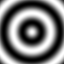

In [ ]:
x←31.5-⍳64
r←√x²+⊗x²
phase←π 2×⍳24 ÷ 24
["fps":12] •image 0.5+0.5×2○phase-⊗r÷3

## Animated SVG

SVG can animate without any script. An `animate` element inside a shape changes one of the shape's attributes over time. Here it grows and shrinks the circle's radius `r`. [`•element`](system/element.qmd) makes both elements:

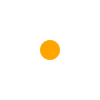

In [ ]:
[circle animate]←•element "circle" "animate"
pulse←["attributeName":"r";"values":"10;40;10";"dur":"2s";"repeatCount":"indefinite"] animate ""
["width":100;"height":100] •svg ["cx":50;"cy":50;"r":10;"fill":"orange"] circle pulse

## Running BPL in a page

A page can load the package straight from jsDelivr. An unversioned URL, such as `https://cdn.jsdelivr.net/npm/basedpl/basedpl_wasm.js`, gives the latest release. Adding a version, as in `basedpl@<version>`, pins one release. `npm install basedpl` installs the package locally instead.

```js
import init, { Session, configure } from 'https://cdn.jsdelivr.net/npm/basedpl/basedpl_wasm.js';

// Fetch the module, which sits beside the glue in the package.
await init();
// Relative file reads resolve against the first argument. The second receives a panic's
// message. After a panic, the module can't run any more code.
configure(location.href, message => console.error(message));
// A session keeps its names from one run to the next.
const session = new Session();
// Each output arrives as it's produced, as {kind, data}. kind is "display" for a displayed
// value, "explicit" for a value assigned to ⎕, or "text" for text written with "-" •nput.
const show = output => console.log(output.data['text/plain']);
// run returns null, or an error object with kind, message and display. display holds the
// error as BPL shows it.
const error = session.run('avg←+/÷≢ ⋄ avg 2 4 9', show);   // logs 5, and error is null
```

`data` maps each MIME type to text, or to a `Uint8Array` for a binary type. The [`•mime`](system/mime.qmd) page lists the types BPL produces, including the pixel and canvas outputs that only the browser build gives.

`run` blocks until the code finishes. Long computations belong in a Web Worker, where they don't freeze the page. The playground and the gallery both run BPL in one. Quick code can run on the main thread instead, where BPL's JavaScript functions can reach the DOM.

## Values and JavaScript functions

`session.eval(code)` returns the value of `code` to JavaScript. It returns `undefined` when the code gives no value, and throws the BPL error object if the code fails.

`session.bind(names)` works the other way round. Each property of the object `names` becomes a BPL name. A JavaScript function becomes a BPL function. Called as `f Y`, it receives `Y`. Called as `X f Y`, it receives `X` then `Y`.

Values convert as the table on the [`•js`](system/js.qmd) page shows:

- Numbers and strings stay as they are.
- A record becomes an object.
- Any other array becomes `{shape, data}`, where `data` is a typed array if every item is a number.

```js
session.bind({ scale: 2, log: x => console.log(x) });
session.eval('scale×1 2 3');   // {shape: [3], data: Float64Array [2, 4, 6]}
session.run('log "hi"', () => {});   // logs "hi"
```

Inside BPL, `•js` makes a BPL function from JavaScript source. Only the browser build has it. In the [playground](playground.qmd), these lines give `5`:

```bpl
h←•js "Math.hypot"
3 h 4
```

Two limits apply to calls into JavaScript:

- Calls are synchronous. BPL can't wait for a promise to settle.
- A Web Worker has no DOM. To change the page, a function bound in the worker has to post a message for the page to act on. No result comes back to BPL.

## How the gallery works

The [gallery](gallery.qmd) runs demos written in BPL, and draws their frames with JavaScript. Four files make it up:

1. [`worker.js`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/playground/worker.js) runs BPL in a Web Worker. It answers `{eval: code}` with the code's value, moving its typed arrays to the page without copying them.
2. [`bpl.js`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/playground/bpl.js) starts the worker and gives the page `run` and `eval`. It also makes the editor, adds the language bar and shows outputs. The playground uses it too.
3. [`gallery.js`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/playground/gallery.js) runs the chosen demo. If the demo defines `frame`, each animation tick evaluates the next `frame i` and hands the result to the driver. An `fps` option in the demo's `options` record sets the frame rate. The driver gets the other options.
4. [`driver.js`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/driver.js) draws one frame: a record holding an `image` and `triangles`, `lines` and `points` matrices, with one shape per row. Its header comment lists the columns and options.

A demo is any BPL file. An animated demo defines `frame`, and can also define `options`. In [`orbits.bpl`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/gallery/orbits.bpl), `frame` gives each dot's position and colour at frame `⍵`.

Your own page needs only the core steps: run the BPL, evaluate a frame on each animation tick, and draw it. This minimal version runs BPL on the page's main thread, and draws with the line-drawing code from above:

```js
import init, { Session, configure } from 'https://cdn.jsdelivr.net/npm/basedpl/basedpl_wasm.js';

await init();
configure(location.href, message => console.error(message));
const session = new Session();
session.run('t←⍳600 ÷ 600 ⋄ frame←{a←π 12×t ⋄ ∨150ⱼ75+70×t×○a+⍵÷10}', () => {});
const ctx = document.querySelector('canvas').getContext('2d');
for (let i = 0; ; i++) {
  const p = session.eval(`frame ${i}`);
  ctx.clearRect(0, 0, ctx.canvas.width, ctx.canvas.height);
  ctx.beginPath();
  for (let j = 0; j < p.data.length; j += 2) ctx.lineTo(p.data[j], p.data[j + 1]);
  ctx.stroke();
  await new Promise(requestAnimationFrame);
}
```

Each frame turns the spiral a little further. The gallery adds a worker, a frame rate and error handling.

## Language bar and highlighting

`lb.js` adds a bar of BPL's glyphs to a page. Clicking a glyph types it into the editor used last. In a textarea marked with `data-bpl`, or a Monaco editor whose language is `bpl`, a backtick followed by a glyph's name also types the glyph, as in the BPL REPL. `lb.js` and `input.js` are scripts whose value is a function. The bar needs the glyph rows from `symbols()` and the key layout from `layout.json`:

```js
import init, { symbols } from 'https://cdn.jsdelivr.net/npm/basedpl/basedpl_wasm.js';

const text = name => fetch(`https://cdn.jsdelivr.net/npm/basedpl/${name}`).then(r => r.text());
const [lb, input, layout] = await Promise.all(['lb.js', 'input.js', 'layout.json'].map(text));
await init();
(0, eval)(lb)(JSON.parse(symbols()), (0, eval)(input), JSON.parse(layout));
```

`bpl.tmLanguage.json` is a TextMate grammar for BPL, with the scope name `source.bpl`. Shiki and editors that read TextMate grammars use it to highlight BPL code.

## Differences from native BPL

- `•js` exists only in the browser build.
- `•readdir`, `•metadata`, `•copy`, `•rename`, `•remove`, `•mkdir`, `•path` and `•delay` don't exist. `•nput` writes only to `"-"`.
- File reads and `•fetch` are synchronous `XMLHttpRequest`s, relative to the URL given to `configure`.
- `•r` uses JavaScript's `RegExp`, with its syntax and replacement templates.
- `•date⁻¹` has no `locale` option.
- Function calls nest at most 380 deep. A deeper call is a `LIMIT` error.